# Training — CNN + Channel-Attention + SVM

Trains the original model and saves all artefacts to a *fixed* folder `saved_models_original/` so that **prunning.ipynb**, **low_rank.ipynb** and **quantization.ipynb** can load exactly the same model.


In [1]:
import os, time, gzip, shutil, json
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape, Multiply, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ----------------------------------------------------------------------------
# Custom ChannelAttention layer (must be identical to training.ipynb so that
# the saved .keras model can be loaded back successfully).
# ----------------------------------------------------------------------------
class ChannelAttention(Layer):
    """Channel Attention Module — same as used in training."""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels      = input_shape[-1]
        self.gap      = GlobalAveragePooling2D()
        self.dense1   = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2   = Dense(channels, activation="sigmoid")
        self.reshape  = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}


In [2]:
import random, os
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"[INFO] enable_op_determinism: {e}")

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except RuntimeError: pass
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("Running on CPU.")


TensorFlow version: 2.10.0
GPU detected: ['/physical_device:GPU:0']


In [3]:
# ============================================================================
# UNIFIED EVALUATION HELPERS  (same definitions across all 4 notebooks)
# ============================================================================

def get_file_size_kb(path):
    """File size in KB, or 0.0 if missing."""
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def fmt_size(kb):
    if kb < 1024: return f"{kb:.2f} KB"
    return f"{kb/1024:.2f} MB"

def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int,
                      class_names, label="Model", warmup=True):
    """Runs feature extraction + scaling + SVM prediction.
    Returns a dict containing accuracy, sensitivity, specificity, F1, AUC,
    confusion matrix, feature-extraction time, inference time."""

    # warm-up so first-call graph compilation does not pollute timing
    if warmup:
        try:
            _ = extractor.predict(X_test[:2], verbose=0)
        except Exception:
            pass

    # ---- timing: feature extraction ----
    t0 = time.perf_counter()
    X_test_feat = extractor.predict(X_test, verbose=0)
    feat_time = time.perf_counter() - t0

    # ---- timing: scaling + SVM inference ----
    t0 = time.perf_counter()
    X_test_scaled = scaler.transform(X_test_feat)
    y_pred        = svm_clf.predict(X_test_scaled)
    y_pred_proba  = svm_clf.predict_proba(X_test_scaled)
    inf_time      = time.perf_counter() - t0

    n_classes = len(class_names)
    cm        = confusion_matrix(y_test_int, y_pred, labels=list(range(n_classes)))

    sens, spec, prec, f1s = [], [], [], []
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        s  = TP/(TP+FN) if (TP+FN)>0 else 0.0
        sp = TN/(TN+FP) if (TN+FP)>0 else 0.0
        p  = TP/(TP+FP) if (TP+FP)>0 else 0.0
        f  = 2*p*s/(p+s) if (p+s)>0 else 0.0
        sens.append(s); spec.append(sp); prec.append(p); f1s.append(f)

    y_test_bin   = label_binarize(y_test_int, classes=list(range(n_classes)))
    auc_per_cls  = roc_auc_score(y_test_bin, y_pred_proba, average=None , multi_class="ovr")
    auc_macro    = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
    auc_micro    = roc_auc_score(y_test_bin, y_pred_proba, average="micro", multi_class="ovr")
    accuracy     = accuracy_score(y_test_int, y_pred)

    return {
        "label"        : label,
        "accuracy"     : accuracy,
        "sensitivity"  : list(sens),
        "specificity"  : list(spec),
        "precision"    : list(prec),
        "f1"           : list(f1s),
        "auc_per_class": list(auc_per_cls),
        "auc_macro"    : auc_macro,
        "auc_micro"    : auc_micro,
        "cm"           : cm,
        "feat_time"    : feat_time,
        "inf_time"     : inf_time,
        "y_pred"       : y_pred,
        "y_pred_proba" : y_pred_proba,
    }


def per_class_metrics_df(metrics, class_names):
    rows = []
    rows.append(["Sensitivity"] + [f"{v:.4f}" for v in metrics["sensitivity" ]] + [f'{np.mean(metrics["sensitivity" ]):.4f}'])
    rows.append(["Specificity"] + [f"{v:.4f}" for v in metrics["specificity" ]] + [f'{np.mean(metrics["specificity" ]):.4f}'])
    rows.append(["Precision"  ] + [f"{v:.4f}" for v in metrics["precision"   ]] + [f'{np.mean(metrics["precision"   ]):.4f}'])
    rows.append(["F1-Score"   ] + [f"{v:.4f}" for v in metrics["f1"          ]] + [f'{np.mean(metrics["f1"          ]):.4f}'])
    rows.append(["AUC"        ] + [f"{v:.4f}" for v in metrics["auc_per_class"]] + [f'{np.mean(metrics["auc_per_class"]):.4f}'])
    return pd.DataFrame(rows, columns=["Metric"] + class_names + ["Mean"])


def print_evaluation_block(metrics, class_names, title="EVALUATION METRICS"):
    print("=" * 78)
    print(f"  {title} — {metrics['label']}")
    print("=" * 78)
    df = per_class_metrics_df(metrics, class_names)
    print(df.to_string(index=False))
    print("-" * 78)
    print(f"Accuracy        : {metrics['accuracy' ]:.4f}")
    print(f"AUC (macro avg) : {metrics['auc_macro']:.4f}")
    print(f"AUC (micro avg) : {metrics['auc_micro']:.4f}")
    print("\nConfusion Matrix (rows=true, cols=pred):")
    cm_df = pd.DataFrame(metrics["cm"], index=class_names, columns=class_names)
    print(cm_df.to_string())
    print("=" * 78)


def resource_table(name_size_param_list):
    """Builds a resource-comparison table.
    Each entry: (label, size_kb, n_params, feat_time_s, inf_time_s)"""
    df = pd.DataFrame(
        name_size_param_list,
        columns=["Model", "Size (KB)", "Parameters",
                 "Feature Extraction (s)", "Inference (s)"]
    )
    return df


def plot_confusion_matrix(metrics, class_names, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title or f"Confusion Matrix — {metrics['label']}")
    return ax


In [4]:
# ============================================================================
# LOAD DATASET (train / valid / test)
# ============================================================================
dataset_base_path = "./dataset_processed2"
img_size          = 224
categories        = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names       = ["Bengin", "Malignant", "Normal"]
num_classes       = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img); y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset…")
X_train, y_train_labels = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid_labels = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test , y_test_labels  = load_split_data(os.path.join(dataset_base_path, "test" ), categories)

y_train     = to_categorical(y_train_labels, num_classes=num_classes)
y_valid     = to_categorical(y_valid_labels, num_classes=num_classes)
y_test      = to_categorical(y_test_labels , num_classes=num_classes)
y_train_int = y_train_labels
y_valid_int = y_valid_labels
y_test_int  = y_test_labels

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


Loading dataset…
Train: (737, 224, 224, 3), Valid: (158, 224, 224, 3), Test: (159, 224, 224, 3)


In [5]:
# ============================================================================
# BUILD CNN + CHANNEL ATTENTION + SVM MODEL  (only run when training)
# ============================================================================
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(inputs)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = ChannelAttention(ratio=8)(x)
    x = MaxPooling2D((2, 2))(x)

    x        = Flatten()(x)
    features = Dense(16, activation="relu", name="feature_layer")(x)
    output   = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    return Model(inputs, output, name="CNN_Attention")

model2 = build_model(X_train.shape[1:], num_classes)
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model2.summary()

history = model2.fit(
    X_train, y_train,
    epochs=30, batch_size=8,
    validation_data=(X_valid, y_valid),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss")],
    verbose=1,
)

# ---------- feature extractor ----------
extractor = Model(inputs=model2.input,
                  outputs=model2.get_layer("feature_layer").output)

# ---------- feature extraction (timed) ----------
t0 = time.perf_counter()
X_train_feat = extractor.predict(X_train, verbose=0)
X_val_feat   = extractor.predict(X_valid, verbose=0)
X_test_feat  = extractor.predict(X_test , verbose=0)
feature_extraction_time = time.perf_counter() - t0
print(f"Feature extraction time (train+val+test): {feature_extraction_time:.4f} s")

# ---------- StandardScaler ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled   = scaler.transform   (X_val_feat  )
X_test_scaled  = scaler.transform   (X_test_feat )

# ---------- SVM (trained on train+valid) ----------
X_svm_train = np.vstack([X_train_scaled, X_val_scaled])
y_svm_train = np.concatenate([y_train_int, y_valid_int])

t0 = time.perf_counter()
svm_clf1 = SVC(kernel="rbf", C=1.0, gamma="scale",
               probability=True, random_state=42)
svm_clf1.fit(X_svm_train, y_svm_train)
svm_training_time = time.perf_counter() - t0
print(f"SVM training time: {svm_training_time:.4f} s")

# ---------- inference timing ----------
t0 = time.perf_counter()
y_pred       = svm_clf1.predict      (X_test_scaled)
y_pred_proba = svm_clf1.predict_proba(X_test_scaled)
inference_time = time.perf_counter() - t0
print(f"Inference time (scaling+SVM): {inference_time:.4f} s")

test_accuracy = accuracy_score(y_test_int, y_pred)
print(f"\nTest accuracy: {test_accuracy:.4f}")
print(classification_report(y_test_int, y_pred, target_names=class_names))


Model: "CNN_Attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 64)      1792      
                                                                 
 channel_attention (ChannelA  (None, 224, 224, 64)     1096      
 ttention)                                                       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      36928     
                                                                 
 channel_attention_1 (Channe  (None, 112, 112, 64)   

In [6]:
# ============================================================================
# SAVE ALL ARTEFACTS TO FIXED FOLDER (so other notebooks load the same files)
# ============================================================================
save_folder = "saved_models_original"
os.makedirs(save_folder, exist_ok=True)

cnn_path       = os.path.join(save_folder, "cnn_attention_model.keras")
extractor_path = os.path.join(save_folder, "feature_extractor.keras")
svm_path       = os.path.join(save_folder, "svm_classifier.pkl")
scaler_path    = os.path.join(save_folder, "feature_scaler.pkl")

model2 .save(cnn_path)
extractor.save(extractor_path)
joblib.dump(svm_clf1, svm_path)
joblib.dump(scaler  , scaler_path)

# training history
hist_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
with open(os.path.join(save_folder, "training_history.json"), "w") as f:
    json.dump(hist_dict, f, indent=2)

# textual info
with open(os.path.join(save_folder, "model_info.txt"), "w") as f:
    f.write("CNN + Channel Attention + SVM\n")
    f.write(f"Final val_accuracy : {history.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"Test accuracy      : {test_accuracy:.4f}\n")

print("Saved files:")
for fn in sorted(os.listdir(save_folder)):
    fp = os.path.join(save_folder, fn)
    print(f"  {fn:<35} {get_file_size_kb(fp):>10.2f} KB")


Saved files:
  cnn_attention_model.keras             38187.68 KB
  feature_extractor.keras               12739.30 KB
  feature_scaler.pkl                        0.98 KB
  model_info.txt                            0.09 KB
  svm_classifier.pkl                        9.39 KB
  training_history.json                     1.27 KB


  EVALUATION METRICS — Original (CNN+Attn+SVM)
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60

RESOURCE TABLE
                  Model    Size (KB)  Parameters  Feature Extraction (s)  Inference (s)
Original (CNN+Attn+SVM) 38198.048828     3252243                0.233247       0.001332


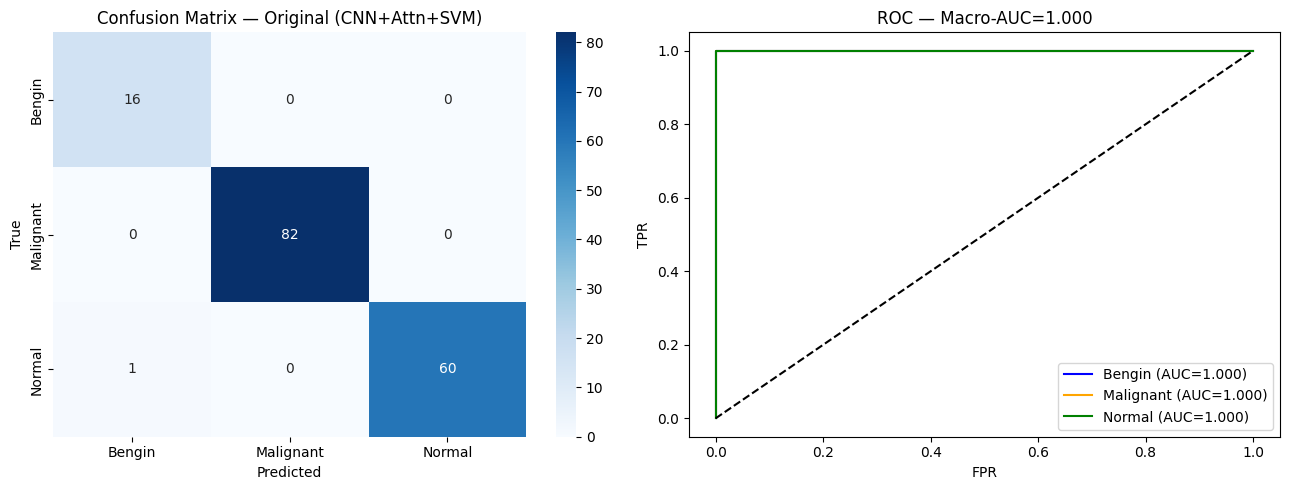

In [7]:
# ============================================================================
# COMPREHENSIVE METRICS TABLES + CONFUSION MATRIX
# ============================================================================
metrics_orig = evaluate_pipeline(
    extractor, svm_clf1, scaler,
    X_test, y_test_int, class_names, label="Original (CNN+Attn+SVM)"
)
print_evaluation_block(metrics_orig, class_names)

# Resource / timing table
res_df = resource_table([
    ("Original (CNN+Attn+SVM)",
     get_file_size_kb(cnn_path) + get_file_size_kb(svm_path) + get_file_size_kb(scaler_path),
     model2.count_params(),
     metrics_orig["feat_time"],
     metrics_orig["inf_time"]),
])
print("\nRESOURCE TABLE")
print(res_df.to_string(index=False))

# Plot confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(metrics_orig, class_names, ax=axes[0])

# ROC
y_test_bin = label_binarize(y_test_int, classes=list(range(num_classes)))
colors = ["blue", "orange", "green"]
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], metrics_orig["y_pred_proba"][:, i])
    axes[1].plot(fpr, tpr, color=colors[i],
                 label=f'{class_names[i]} (AUC={metrics_orig["auc_per_class"][i]:.3f})')
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title(f'ROC — Macro-AUC={metrics_orig["auc_macro"]:.3f}')
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()
